<a href="https://colab.research.google.com/github/zs2770-rgb/Hello-World/blob/main/MasterThesis_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Set Up, Clean, and Load

In [ ]:
import argparse
import json
import sys
import csv
import html


def iter_jsonl(path, encoding="utf-8"):
    with open(path, "r", encoding=encoding) as fp:
        for lineno, line in enumerate(fp, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                yield json.loads(line)
            except json.JSONDecodeError as exc:
                print(f"Skipping malformed JSON on line {lineno}: {exc}", file=sys.stderr)


def main():
    parser = argparse.ArgumentParser(description="Read and print JSONL reviews")
    parser.add_argument("path", nargs="?",
                        default="/Users/taylorsong/Downloads/All_Beauty.jsonl",
                        help="Path to the .jsonl file")
    parser.add_argument("--pretty", action="store_true", help="Pretty-print JSON objects")
    parser.add_argument("--count", action="store_true", help="Only print the total number of records")
    parser.add_argument("--to-csv", help="Write output to CSV file")
    parser.add_argument("--html", help="Write output to HTML table file")
    parser.add_argument("--fields", help="Comma-separated fields to export (supports dot notation)",
                        default="rating,title,text,images,asin,parent_asin,user_id,timestamp,verified_purchase,helpful_vote")
    parser.add_argument("--limit", type=int, default=0, help="Limit number of records processed (0 = no limit)")
    parser.add_argument("--schema", action="store_true", help="Print or export the dataset schema (fields, types, explanations)")
    args = parser.parse_args()

    fields = [f.strip() for f in args.fields.split(",")] if args.fields else []

    # schema definition (Field, Type, Explanation)
    SCHEMA = [
        ("rating", "float", "Rating of the product (from 1.0 to 5.0)."),
        ("title", "str", "Title of the user review."),
        ("text", "str", "Text body of the user review."),
        ("images", "list", "Images that users post after they have received the product. Each image has different sizes (small, medium, large) represented by small_image_url, medium_image_url, large_image_url."),
        ("asin", "str", "ID of the product."),
        ("parent_asin", "str", "Parent ID of the product. Use parent ID to find product metadata."),
        ("user_id", "str", "ID of the reviewer."),
        ("timestamp", "int", "Time of the review (unix time)."),
        ("verified_purchase", "bool", "User purchase verification."),
        ("helpful_vote", "int", "Helpful votes of the review."),
    ]

    # If user requested schema, output it and exit (supports CSV/HTML export via --to-csv/--html)
    if args.schema:
        # CSV export
        if args.to_csv:
            with open(args.to_csv, "w", newline="", encoding="utf-8") as sf:
                w = csv.writer(sf)
                w.writerow(["Field", "Type", "Explanation"])
                for row in SCHEMA:
                    w.writerow(row)
            print(f"Schema written to {args.to_csv}")
            return

        # HTML export
        if args.html:
            with open(args.html, "w", encoding="utf-8") as hf:
                hf.write("<!doctype html>\n<html><head><meta charset=\"utf-8\">\n")
                hf.write("<style>table{border-collapse:collapse;width:100%}th,td{border:1px solid #ccc;padding:6px;text-align:left;vertical-align:top}th{background:#f6f6f6}</style>\n")
                hf.write("</head><body>\n")
                hf.write("<table>\n<thead><tr><th>Field</th><th>Type</th><th>Explanation</th></tr></thead>\n<tbody>\n")
                for f, t, e in SCHEMA:
                    hf.write(f"<tr><td>{html.escape(f)}</td><td>{html.escape(t)}</td><td>{html.escape(e)}</td></tr>\n")
                hf.write("</tbody></table>\n</body></html>")
            print(f"Schema written to {args.html}")
            return

        # Default: print to stdout in a simple table format
        # compute column widths
        col1 = max(len(r[0]) for r in SCHEMA + [("Field", "", "")])
        col2 = max(len(r[1]) for r in SCHEMA + [("", "Type", "")])
        print(f"{'Field'.ljust(col1)}  {'Type'.ljust(col2)}  Explanation")
        print(f"{'-'*col1}  {'-'*col2}  {'-'*40}")
        for f, t, e in SCHEMA:
            print(f"{f.ljust(col1)}  {t.ljust(col2)}  {e}")
        return

    if args.count:
        total = 0
        for _ in iter_jsonl(args.path):
            total += 1
        print(total)
        return

    # helpers for exporting fields
    def get_field(obj, field_name):
        # support dot notation for nested fields
        parts = field_name.split(".")
        cur = obj
        for p in parts:
            if isinstance(cur, dict) and p in cur:
                cur = cur[p]
            else:
                return ""
        # convert timestamp (milliseconds or seconds) to ISO-8601 UTC datetime
        if field_name == "timestamp":
            try:
                # some timestamps are in milliseconds
                ts = int(cur)
                if ts > 10**12:
                    # milliseconds
                    ts_sec = ts / 1000.0
                else:
                    ts_sec = ts
                from datetime import datetime, timezone

                dt = datetime.fromtimestamp(ts_sec, tz=timezone.utc)
                return dt.isoformat()
            except Exception:
                return str(cur)

        # serialize lists/dicts cleanly
        if isinstance(cur, (dict, list)):
            return json.dumps(cur, ensure_ascii=False)
        return cur

    limit = args.limit if args.limit and args.limit > 0 else None

    # CSV writer (streaming)
    csv_fp = None
    csv_writer = None
    if args.to_csv:
        csv_fp = open(args.to_csv, "w", newline="", encoding="utf-8")
        csv_writer = csv.writer(csv_fp)
        csv_writer.writerow(fields)

    # HTML writer (streaming)
    html_fp = None
    if args.html:
        html_fp = open(args.html, "w", encoding="utf-8")
        # simple HTML with a table; JS libraries can be added later if needed
        html_fp.write("<!doctype html>\n<html><head><meta charset=\"utf-8\">\n")
        html_fp.write("<style>table{border-collapse:collapse;width:100%}th,td{border:1px solid #ccc;padding:6px;text-align:left;vertical-align:top}th{background:#f6f6f6}</style>\n")
        html_fp.write("</head><body>\n")
        html_fp.write("<table>\n<thead><tr>")
        for h in fields:
            html_fp.write(f"<th>{html.escape(h)}</th>")
        html_fp.write("</tr></thead>\n<tbody>\n")

    processed = 0
    for obj in iter_jsonl(args.path):
        processed += 1
        if fields:
            row = [get_field(obj, f) for f in fields]
        else:
            # fallback: write the full object JSON in a single column
            row = [json.dumps(obj, ensure_ascii=False)]

        if csv_writer:
            # ensure all values are strings for CSV
            csv_writer.writerow([str(v) for v in row])

        if html_fp:
            html_fp.write("<tr>")
            for v in row:
                html_fp.write(f"<td>{html.escape(str(v))}</td>")
            html_fp.write("</tr>\n")

        if not (args.to_csv or args.html):
            # print to stdout
            if args.pretty:
                print(json.dumps(obj, ensure_ascii=False, indent=2))
            else:
                print(json.dumps(obj, ensure_ascii=False))

        if limit and processed >= limit:
            break

    if html_fp:
        html_fp.write("</tbody></table>\n</body></html>")
        html_fp.close()

    if csv_fp:
        csv_fp.close()


if __name__ == "__main__":
    main()

In [ ]:
import re
import numpy as np
import pandas as pd

from collections import Counter
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

PATH = "/content/allbeauty_table.csv"
df = pd.read_csv(PATH, engine='python', on_bad_lines='skip')

# Column map (based on your schema)
TEXT_COL = "text"
TITLE_COL = "title"
RATING_COL = "rating"
TIME_COL = "timestamp"
HELPFUL_COL = "helpful_vote"
VERIFIED_COL = "verified_purchase"

print(df.shape)
print(df.dtypes)
df.head(2)

(183155, 10)
rating               float64
title                 object
text                  object
images                object
asin                  object
parent_asin           object
user_id               object
timestamp             object
verified_purchase       bool
helpful_vote           int64
dtype: object


,rating,title,text,images,asin,parent_asin,user_id,timestamp,verified_purchase,helpful_vote
0,5.0,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05T14:08:48.923000+00:00,True,0
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04T18:10:55.070000+00:00,True,1


## Parse timestamps + filter window

In [ ]:
df["dt"] = pd.to_datetime(df[TIME_COL], errors="coerce", utc=True)
df = df[df["dt"].notna()].copy()

# your thesis window
df = df[(df["dt"] >= "2018-01-01") & (df["dt"] < "2024-01-01")].copy()

df["year"] = df["dt"].dt.year
df["month"] = df["dt"].dt.to_period("M").dt.to_timestamp()

print(df["dt"].min(), df["dt"].max())

2018-01-01 00:50:42.850000+00:00 2023-04-01 22:38:17.481000+00:00


/tmp/ipykernel_19982/3487938963.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["dt"].dt.to_period("M").dt.to_timestamp()


## Clean Text and Length Measures

In [ ]:
def clean_text(x) -> str:
    if pd.isna(x):
        return ""
    x = str(x).lower()
    x = re.sub(r"http\S+|www\.\S+", " ", x)
    x = re.sub(r"[^a-z0-9\s']", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

df["text_clean"] = df[TEXT_COL].map(clean_text)
df["title_clean"] = df[TITLE_COL].map(clean_text)

# Use combined text (title + review body) for better phrase capture
df["doc_clean"] = (df["title_clean"] + " " + df["text_clean"]).str.strip()

df["n_words"] = df["doc_clean"].map(lambda s: len(s.split()))
df = df[df["n_words"] > 0].copy()

# Numeric housekeeping
df[RATING_COL] = pd.to_numeric(df[RATING_COL], errors="coerce")
df = df[df[RATING_COL].between(1, 5)].copy()

df[HELPFUL_COL] = pd.to_numeric(df[HELPFUL_COL], errors="coerce").fillna(0).astype(int)
df["helpful_log1p"] = np.log1p(df[HELPFUL_COL])

# Verified is already bool per your schema
df["verified"] = df[VERIFIED_COL].astype(int)

df["log_len"] = np.log1p(df["n_words"])

df[[RATING_COL, HELPFUL_COL, "verified", "n_words"]].describe()

,rating,helpful_vote,verified,n_words
count,128564.000000,128564.000000,128564.000000,128564.000000
mean,4.017439,0.820090,0.893306,39.379220
std,1.438683,6.127606,0.308725,48.465257
min,1.000000,0.000000,0.000000,1.000000
25%,3.000000,0.000000,1.000000,12.000000
50%,5.000000,0.000000,1.000000,25.000000
75%,5.000000,0.000000,1.000000,48.000000
max,5.000000,646.000000,1.000000,1617.000000


## 1) Phrase Dictionary + Measurement (Used by all hypotheses)
Start with your dictionary (expand later)

In [ ]:
PHRASES = {
    "functional": [
        "acne", "breakout", "breakouts", "cleared my skin", "reduced acne",
        "hydration", "more hydrated", "dryness", "moisturizing",
        "dark spots", "hyperpigmentation", "brightened", "brightening",
        "wrinkles", "fine lines", "anti aging", "anti-aging", "firming",
        "oil control", "less oily", "reduced redness", "calmed", "soothed"
    ],
    "sensory": [
        "smell", "scent", "fragrance", "no smell", "no scent", "unscented",
        "texture", "creamy", "sticky", "greasy", "lightweight",
        "packaging", "bottle", "pump", "applicator",
        "shipping", "arrived", "delivery", "leaked"
    ],
    "timebound": [
        "after two weeks", "after 2 weeks", "within a month", "after a month",
        "in a few days", "overnight", "immediately", "right away",
        "after one week", "after 1 week", "in weeks", "in days"
    ],
}

# Safety: only keep non-empty strings
PHRASES = {k: [p for p in v if isinstance(p, str) and p.strip()] for k, v in PHRASES.items()}

### Phrase hit / presence functions (robust)

In [ ]:
def count_phrase_hits(text: str, phrases: list[str]) -> int:
    text = "" if pd.isna(text) else str(text)
    hits = 0
    for p in phrases:
        if p in text:
            hits += 1
    return hits

def any_phrase_present(text: str, phrases: list[str]) -> int:
    text = "" if pd.isna(text) else str(text)
    for p in phrases:
        if p in text:
            return 1
    return 0

# Compute hits/presence/shares
for k, plist in PHRASES.items():
    df[f"{k}_hits"] = df["doc_clean"].map(lambda s: count_phrase_hits(s, plist))
    df[f"{k}_present"] = df["doc_clean"].map(lambda s: any_phrase_present(s, plist))
    df[f"{k}_share"] = df[f"{k}_hits"] / df["n_words"]

df[[f"{k}_hits" for k in PHRASES] + [f"{k}_present" for k in PHRASES] + ["n_words"]].head(5)

,functional_hits,sensory_hits,timebound_hits,functional_present,sensory_present,timebound_present,n_words
0,0,3,0,0,1,0,68
1,0,1,0,0,1,0,54
2,0,1,0,0,1,0,5
3,0,0,0,0,0,0,4
4,0,0,0,0,0,0,3


## H1 — Attribute Salience (What consumers talk about most)
H1-A) Category-level salience summary (managerial + thesis-friendly)

In [ ]:
h1_cat = []
for k in PHRASES.keys():
    h1_cat.append({
        "category": k,
        "present_rate": df[f"{k}_present"].mean(),   # % reviews mentioning category
        "mean_share": df[f"{k}_share"].mean(),       # avg normalized density
        "mean_hits": df[f"{k}_hits"].mean()          # avg distinct phrase hits
    })

h1_cat_df = pd.DataFrame(h1_cat).sort_values("present_rate", ascending=False)
h1_cat_df

,category,present_rate,mean_share,mean_hits
1,sensory,0.191344,0.009115,0.256518
0,functional,0.021367,0.000606,0.025956
2,timebound,0.012041,0.000266,0.012266


## H1-B) Phrase ranking: top phrases consumers use (your advertising deliverable)

This counts how many reviews contain each phrase at least once.

In [ ]:
rows = []
for cat, plist in PHRASES.items():
    for p in plist:
        cnt = int(df["doc_clean"].str.contains(re.escape(p), regex=True).sum())
        rows.append({"category": cat, "phrase": p, "review_count": cnt, "share_of_reviews": cnt/len(df)})

h1_phrase_rank = (pd.DataFrame(rows)
                  .sort_values("review_count", ascending=False)
                  .reset_index(drop=True))

h1_phrase_rank.head(30)

,category,phrase,review_count,share_of_reviews
0,sensory,smell,9434,0.073380
1,sensory,scent,5687,0.044235
2,sensory,bottle,4238,0.032964
3,sensory,arrived,1666,0.012959
4,sensory,packaging,1575,0.012251
5,sensory,texture,1527,0.011877
6,sensory,fragrance,1439,0.011193
7,functional,moisturizing,1302,0.010127
8,sensory,sticky,1204,0.009365
9,sensory,greasy,1159,0.009015


Top 15 per category

In [ ]:
top_k = 15
h1_top_by_cat = (h1_phrase_rank
                 .sort_values(["category","review_count"], ascending=[True, False])
                 .groupby("category")
                 .head(top_k)
                 .reset_index(drop=True))

h1_top_by_cat

,category,phrase,review_count,share_of_reviews
0,functional,moisturizing,1302,0.010127
1,functional,acne,415,0.003228
2,functional,wrinkles,333,0.002590
3,functional,breakout,244,0.001898
4,functional,fine lines,188,0.001462
5,functional,breakouts,170,0.001322
6,functional,hydration,164,0.001276
7,functional,dryness,149,0.001159
8,functional,anti aging,76,0.000591
9,functional,dark spots,74,0.000576


### H1-C) Visualization (simple, clean)

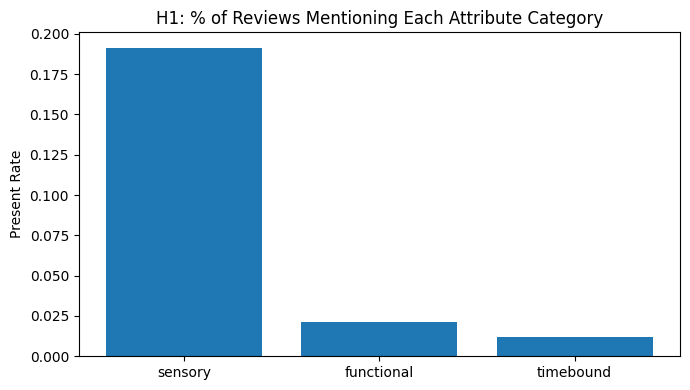

In [ ]:
plt.figure(figsize=(7,4))
plt.bar(h1_cat_df["category"], h1_cat_df["present_rate"])
plt.title("H1: % of Reviews Mentioning Each Attribute Category")
plt.ylabel("Present Rate")
plt.tight_layout()
plt.show()

## H2 — Rating Association (Which attribute language aligns with higher satisfaction?)

Hypothesis: Reviews mentioning functional attributes are associated with higher star ratings.



### H2-A) Simple mean comparison (easy to interpret)

In [ ]:
mean_yes = df.loc[df["functional_present"]==1, RATING_COL].mean()
mean_no  = df.loc[df["functional_present"]==0, RATING_COL].mean()

print("Mean rating when functional mentioned:", mean_yes)
print("Mean rating when functional NOT mentioned:", mean_no)
print("Difference:", mean_yes - mean_no)

Mean rating when functional mentioned: 4.335638878776847
Mean rating when functional NOT mentioned: 4.01049142802642
Difference: 0.3251474507504275


### H2-B) Main regression (presence indicators + controls + year FE)

This is the thesis-grade model.

In [ ]:
h2_formula = (
    "rating ~ functional_present + sensory_present + timebound_present "
    "+ log_len + verified + C(year)"
)
h2_model = smf.ols(h2_formula, data=df).fit(cov_type="HC3")
print(h2_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     236.0
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:02:58   Log-Likelihood:            -2.2812e+05
No. Observations:              128564   AIC:                         4.563e+05
Df Residuals:                  128553   BIC:                         4.564e+05
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.7450      0

### H2-C) Robustness: use shares instead of presence

In [ ]:
h2_formula_share = (
    "rating ~ functional_share + sensory_share + timebound_share "
    "+ log_len + verified + C(year)"
)
h2_model_share = smf.ols(h2_formula_share, data=df).fit(cov_type="HC3")
print(h2_model_share.summary())

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     223.6
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:02:59   Log-Likelihood:            -2.2813e+05
No. Observations:              128564   AIC:                         4.563e+05
Df Residuals:                  128553   BIC:                         4.564e+05
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            4.7147      0.023  

## H3 — Helpfulness Association (What attribute language is perceived as useful?)

Hypothesis: Reviews that mention attribute-specific language receive more helpful votes.

### H3-A) Any-attribute indicator

In [ ]:
df["any_attr_present"] = (
    (df["functional_present"]==1) |
    (df["sensory_present"]==1) |
    (df["timebound_present"]==1)
).astype(int)

df["any_attr_present"].mean()

np.float64(0.2098876823994275)

### H3-B) Regression on log(1 + helpful_vote)

In [ ]:
h3_formula = "helpful_log1p ~ any_attr_present + log_len + verified + C(year)"
h3_model = smf.ols(h3_formula, data=df).fit(cov_type="HC3")
print(h3_model.summary())

                            OLS Regression Results                            
Dep. Variable:          helpful_log1p   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     1065.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:02:59   Log-Likelihood:            -1.0380e+05
No. Observations:              128564   AIC:                         2.076e+05
Df Residuals:                  128555   BIC:                         2.077e+05
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.3834      0.009  

### H3-C) Robustness: Count model (Poisson) on helpful votes (optional but strong)

Poisson is standard for skewed count outcomes. Use robust SE.

In [ ]:
h3_pois_formula = "helpful_vote ~ any_attr_present + log_len + verified + C(year)"
h3_pois = smf.glm(h3_pois_formula, data=df, family=sm.families.Poisson()).fit(cov_type="HC3")
print(h3_pois.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           helpful_vote   No. Observations:               128564
Model:                            GLM   Df Residuals:                   128555
Model Family:                 Poisson   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.5345e+05
Date:                Tue, 07 Apr 2026   Deviance:                   4.2793e+05
Time:                        01:03:00   Pearson chi2:                 3.73e+06
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4707
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -4.2351      0.148  

## H4 — Category Differences in Helpfulness (Which attribute type matters most?)

Hypothesis: Functional vs sensory vs time-bound differ in helpfulness association.

### H4-A) Regression with category indicators

In [ ]:
h4_formula = (
    "helpful_log1p ~ functional_present + sensory_present + timebound_present "
    "+ log_len + verified + C(year)"
)
h4_model = smf.ols(h4_formula, data=df).fit(cov_type="HC3")
print(h4_model.summary())

                            OLS Regression Results                            
Dep. Variable:          helpful_log1p   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     853.1
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:03:01   Log-Likelihood:            -1.0379e+05
No. Observations:              128564   AIC:                         2.076e+05
Df Residuals:                  128553   BIC:                         2.077e+05
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.3830      0

### H4-B) Wald tests: compare category effects

In [ ]:
print("Test functional = sensory")
print(h4_model.wald_test("functional_present = sensory_present"))

print("\nTest functional = timebound")
print(h4_model.wald_test("functional_present = timebound_present"))

print("\nTest sensory = timebound")
print(h4_model.wald_test("sensory_present = timebound_present"))

Test functional = sensory
<Wald test (chi2): statistic=[[5.49552773]], p-value=0.01906517274995608, df_denom=1>

Test functional = timebound
<Wald test (chi2): statistic=[[0.29669482]], p-value=0.585961928063083, df_denom=1>

Test sensory = timebound
<Wald test (chi2): statistic=[[1.21225898]], p-value=0.2708851980805673, df_denom=1>


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


# Managerial Output: “Ad Copy Playbook” Table (Top phrases + rating/helpfulness lift)

This is what an advertising team will love: which phrases are common and whether they correlate with better outcomes.

In [ ]:
top_n = 25
top_phrases = h1_phrase_rank.head(top_n)["phrase"].tolist()

playbook_rows = []
for p in top_phrases:
    mask = df["doc_clean"].str.contains(re.escape(p), regex=True)
    if mask.sum() < 30:
        continue  # avoid unstable tiny samples

    playbook_rows.append({
        "phrase": p,
        "mentions": int(mask.sum()),
        "share_of_reviews": float(mask.mean()),
        "avg_rating_when_mentioned": float(df.loc[mask, RATING_COL].mean()),
        "avg_rating_when_not_mentioned": float(df.loc[~mask, RATING_COL].mean()),
        "rating_lift": float(df.loc[mask, RATING_COL].mean() - df.loc[~mask, RATING_COL].mean()),
        "avg_helpful_when_mentioned": float(df.loc[mask, HELPFUL_COL].mean()),
        "avg_helpful_when_not_mentioned": float(df.loc[~mask, HELPFUL_COL].mean()),
        "helpful_lift": float(df.loc[mask, HELPFUL_COL].mean() - df.loc[~mask, HELPFUL_COL].mean()),
    })

ad_copy_playbook = (pd.DataFrame(playbook_rows)
                    .sort_values("mentions", ascending=False)
                    .reset_index(drop=True))

ad_copy_playbook.head(30)

,phrase,mentions,share_of_reviews,avg_rating_when_mentioned,avg_rating_when_not_mentioned,rating_lift,avg_helpful_when_mentioned,avg_helpful_when_not_mentioned,helpful_lift
0,smell,9434,0.073380,4.027454,4.016646,0.010808,1.140237,0.794737,0.345501
1,scent,5687,0.044235,4.242835,4.007007,0.235828,1.089678,0.807612,0.282066
2,bottle,4238,0.032964,3.870222,4.022457,-0.152235,1.189240,0.807506,0.381734
3,arrived,1666,0.012959,3.692677,4.021702,-0.329025,1.048019,0.817097,0.230922
4,packaging,1575,0.012251,3.838095,4.019663,-0.181568,1.083175,0.816827,0.266348
5,texture,1527,0.011877,4.026850,4.017326,0.009524,1.377210,0.813393,0.563817
6,fragrance,1439,0.011193,4.279361,4.014474,0.264887,1.088256,0.817054,0.271202
7,moisturizing,1302,0.010127,4.342550,4.014113,0.328437,0.899386,0.819278,0.080107
8,sticky,1204,0.009365,3.710133,4.020344,-0.310211,1.093854,0.817502,0.276352
9,greasy,1159,0.009015,4.217429,4.015619,0.201809,1.742882,0.811695,0.931187


Save outputs (for thesis appendix + slides):

In [ ]:
h1_cat_df.to_csv("/content/H1_category_salience.csv", index=False)
h1_phrase_rank.to_csv("/content/H1_phrase_rank_all.csv", index=False)
h1_top_by_cat.to_csv("/content/H1_top_phrases_by_category.csv", index=False)
ad_copy_playbook.to_csv("/content/Advertising_Copy_Playbook.csv", index=False)

print("Saved outputs to /content/")

Saved outputs to /content/


Two “Professional Researcher” Robustness Checks (Strongly recommended)
R1) Remove very short reviews (noise)

In [ ]:
df_r1 = df[df["n_words"] >= 10].copy()
h2_r1 = smf.ols(h2_formula, data=df_r1).fit(cov_type="HC3")
print(h2_r1.summary())

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     94.37
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          1.98e-195
Time:                        01:03:04   Log-Likelihood:            -1.8834e+05
No. Observations:              104935   AIC:                         3.767e+05
Df Residuals:                  104924   BIC:                         3.768e+05
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.4092      0

R2) Verified-only sample (credibility filter)

In [ ]:
df_r2 = df[df["verified"] == 1].copy()
h2_r2 = smf.ols(h2_formula, data=df_r2).fit(cov_type="HC3")
print(h2_r2.summary())

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                    0.9955
Date:                Tue, 07 Apr 2026   Prob (F-statistic):              0.318
Time:                        01:03:04   Log-Likelihood:            -2.0486e+05
No. Observations:              114847   AIC:                         4.097e+05
Df Residuals:                  114837   BIC:                         4.098e+05
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           3.068e+11   3.07

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 1
  warnings.warn('covariance of constraints does not have full '


LDA sample size: 128564
Document-term matrix shape: (128564, 1500)

Perplexity by number of topics:
4 topics: 745.26
5 topics: 743.15
6 topics: 732.25

Using final LDA model with 5 topics.

Top words by topic:

Topic 1: color, money, brush, work, nails, nail, colors, polish, time, brushes, pretty, waste
Topic 2: smell, scent, smells, bottle, size, soap, spray, highly, years, body, best, oil
Topic 3: quality, price, perfect, stars, cute, beautiful, wig, value, gift, daughter, easy, looks
Topic 4: hair, head, soft, long, hold, shampoo, small, brush, little, work, does, easy
Topic 5: skin, face, easy, lashes, dry, does, feel, makeup, mask, day, apply, soft

Dominant topic counts:
dominant_topic
1    33189
2    22353
3    24358
4    23895
5    24769
Name: count, dtype: int64

Topic share by year:
dominant_topic      1      2      3      4      5
year                                             
2018            0.240  0.181  0.243  0.159  0.177
2019            0.267  0.171  0.206  0.173  0.

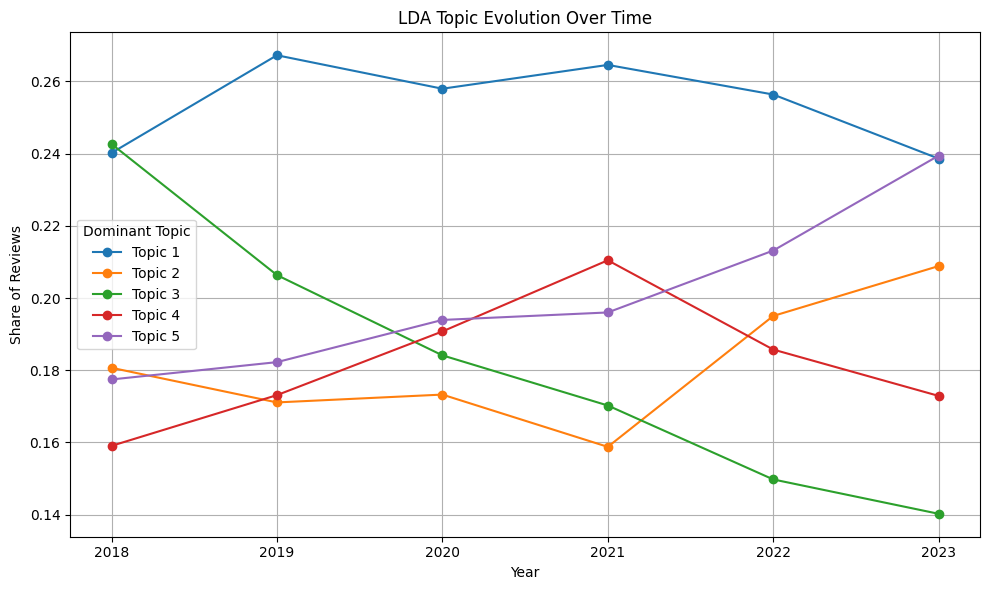


Saved:
/content/LDA_topic_keywords.csv
/content/LDA_topic_evolution.csv
/content/LDA_document_topics.csv


In [ ]:
# =========================
# H6 — Cleaner LDA for Thesis
# =========================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction import text

# -------------------------
# 1. Prepare text
# -------------------------
# Assumes df["doc_clean"] and df["year"] already exist
lda_df = df.copy()

# Remove empty docs just in case
lda_df = lda_df[lda_df["doc_clean"].notna()].copy()
lda_df["doc_clean"] = lda_df["doc_clean"].astype(str).str.strip()
lda_df = lda_df[lda_df["doc_clean"] != ""].copy()

print("LDA sample size:", len(lda_df))

# -------------------------
# 2. Custom stopwords
# -------------------------
# These are generic review words that make topics muddy
custom_stopwords = set(text.ENGLISH_STOP_WORDS).union({
    "product", "products", "item", "amazon",
    "use", "used", "using", "tried", "try",
    "like", "just", "really", "very", "also",
    "good", "great", "nice", "love", "loved",
    "works", "worked", "working",
    "buy", "bought", "purchase",
    "one", "two", "got", "did", "didn", "don", "doesn",
    "ve", "ll", "br"
})

# -------------------------
# 3. Vectorize text
# -------------------------
# Key upgrades:
# - bigrams for phrases like "dark spots", "fine lines"
# - min_df/max_df to reduce noise
# - moderate max_features for clearer topics
vectorizer = CountVectorizer(
    max_features=1500,
    stop_words=list(custom_stopwords),
    min_df=20,
    max_df=0.60,
    ngram_range=(1, 2)
)

dtm = vectorizer.fit_transform(lda_df["doc_clean"])
feature_names = vectorizer.get_feature_names_out()

print("Document-term matrix shape:", dtm.shape)

# -------------------------
# 4. Train multiple LDA models
# -------------------------
# We test a few topic counts, then inspect and choose
topic_candidates = [4, 5, 6]

lda_models = {}
perplexity_scores = {}

for k in topic_candidates:
    lda = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        learning_method="batch",
        max_iter=20
    )
    lda.fit(dtm)
    lda_models[k] = lda
    perplexity_scores[k] = lda.perplexity(dtm)

print("\nPerplexity by number of topics:")
for k, score in perplexity_scores.items():
    print(f"{k} topics: {score:.2f}")

# -------------------------
# 5. Choose final model
# -------------------------
# For thesis clarity, you can manually pick the cleanest one after inspection.
# Defaulting to 5 here because it is usually a good balance.
N_TOPICS = 5
lda_model = lda_models[N_TOPICS]

print(f"\nUsing final LDA model with {N_TOPICS} topics.")

# -------------------------
# 6. Print top words per topic
# -------------------------
def print_top_words(model, feature_names, n_top_words=12):
    print("\nTop words by topic:\n")
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

print_top_words(lda_model, feature_names, n_top_words=12)

# -------------------------
# 7. Topic distribution for each review
# -------------------------
lda_output = lda_model.transform(dtm)

# Dominant topic
lda_df["dominant_topic"] = lda_output.argmax(axis=1) + 1  # 1-based labels

# Full topic probabilities
for i in range(N_TOPICS):
    lda_df[f"topic_{i+1}_prob"] = lda_output[:, i]

print("\nDominant topic counts:")
print(lda_df["dominant_topic"].value_counts().sort_index())

# -------------------------
# 8. Topic evolution over time
# -------------------------
topic_evolution = (
    lda_df.groupby(["year", "dominant_topic"])
    .size()
    .unstack(fill_value=0)
)

# Convert to yearly shares
topic_evolution_share = topic_evolution.div(topic_evolution.sum(axis=1), axis=0)

print("\nTopic share by year:")
print(topic_evolution_share.round(3))

# -------------------------
# 9. Plot topic evolution
# -------------------------
plt.figure(figsize=(10, 6))
for topic in topic_evolution_share.columns:
    plt.plot(
        topic_evolution_share.index,
        topic_evolution_share[topic],
        marker="o",
        label=f"Topic {topic}"
    )

plt.title("LDA Topic Evolution Over Time")
plt.xlabel("Year")
plt.ylabel("Share of Reviews")
plt.legend(title="Dominant Topic")
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------
# 10. Suggested manual labels
# -------------------------
# After you inspect the printed top words, replace these with real labels.
# Example only:
topic_labels = {
    1: "Topic 1",
    2: "Topic 2",
    3: "Topic 3",
    4: "Topic 4",
    5: "Topic 5"
}

lda_df["dominant_topic_label"] = lda_df["dominant_topic"].map(topic_labels)

# -------------------------
# 11. Save outputs
# -------------------------
# Topic keywords table
topic_rows = []
for topic_idx, topic in enumerate(lda_model.components_):
    top_indices = topic.argsort()[:-13:-1]
    top_words = [feature_names[i] for i in top_indices]
    topic_rows.append({
        "topic": topic_idx + 1,
        "top_words": ", ".join(top_words)
    })

topic_keywords_df = pd.DataFrame(topic_rows)

# Topic prevalence by year
topic_evolution_share_reset = topic_evolution_share.reset_index()

# Save
topic_keywords_df.to_csv("/content/LDA_topic_keywords.csv", index=False)
topic_evolution_share_reset.to_csv("/content/LDA_topic_evolution.csv", index=False)
lda_df[["year", "doc_clean", "dominant_topic"] + [f"topic_{i+1}_prob" for i in range(N_TOPICS)]].to_csv(
    "/content/LDA_document_topics.csv", index=False
)

print("\nSaved:")
print("/content/LDA_topic_keywords.csv")
print("/content/LDA_topic_evolution.csv")
print("/content/LDA_document_topics.csv")

## H6 — Topic Discovery (LDA) and Evolution Over Time

Extract interpretable topics using Latent Dirichlet Allocation (LDA) and see how their prevalence changes across years.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

print("Vectorizing text...")
# Use a max of 1000 features to keep it relatively fast and focused on top words
vectorizer = CountVectorizer(max_features=1000, stop_words='english', min_df=10)
dtm = vectorizer.fit_transform(df['doc_clean'])

N_TOPICS = 5
print(f"Training LDA with {N_TOPICS} topics...")
lda_model = LatentDirichletAllocation(n_components=N_TOPICS, random_state=42, n_jobs=-1)
lda_output = lda_model.fit_transform(dtm)

# Display top words for each topic
feature_names = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-10 - 1:-1]]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

# Assign dominant topic to each document
df['dominant_topic'] = lda_output.argmax(axis=1)
print("Topic assignment complete!")


Vectorizing text...
Training LDA with 5 topics...
Topic 1: skin, love, like, use, great, product, scent, smell, face, good
Topic 2: hair, like, don, money, wig, just, head, work, soft, doesn
Topic 3: br, color, like, just, product, use, did, don, used, didn
Topic 4: great, good, love, quality, price, perfect, nice, cute, stars, colors
Topic 5: great, product, works, hair, use, brush, love, easy, good, nails
Topic assignment complete!


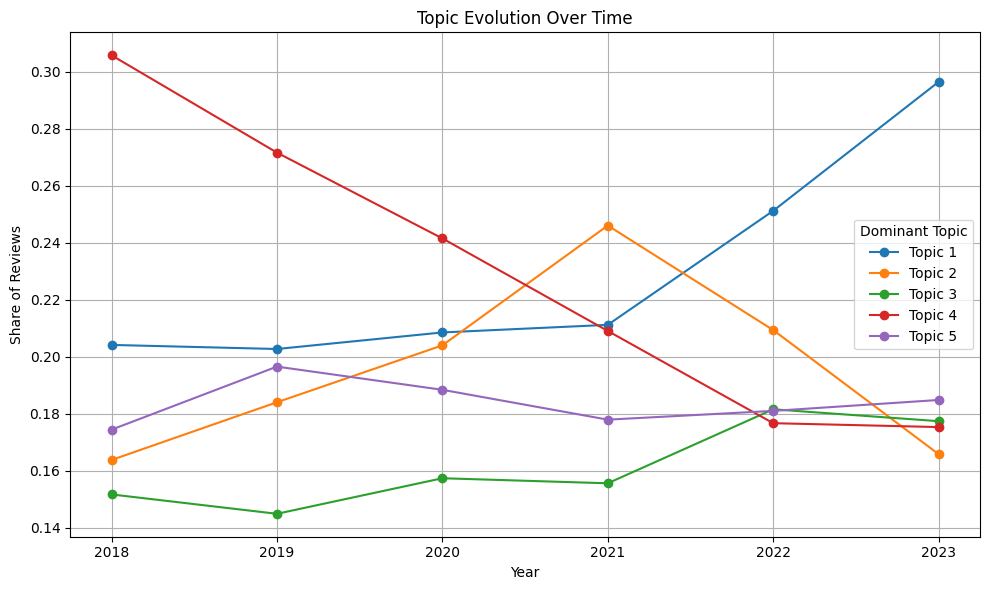

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate topic shares per year
topic_evolution = df.groupby(['year', 'dominant_topic']).size().unstack(fill_value=0)
topic_evolution = topic_evolution.div(topic_evolution.sum(axis=1), axis=0)

plt.figure(figsize=(10, 6))
for topic in topic_evolution.columns:
    plt.plot(topic_evolution.index, topic_evolution[topic], marker='o', label=f'Topic {topic + 1}')

plt.title('Topic Evolution Over Time')
plt.xlabel('Year')
plt.ylabel('Share of Reviews')
plt.legend(title='Dominant Topic')
plt.grid(True)
plt.tight_layout()
plt.show()
